<a href="https://colab.research.google.com/github/Shifali1094/stance-detection/blob/main/notebooks/bertweet_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 1. Install libraries
# =========================
!pip install -q transformers datasets evaluate accelerate emoji vncorenlp
!git clone https://github.com/Shifali1094/stance-detection.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 29.8 MB/s eta 0:00:00
Cloning into 'stance-detection'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 60 (delta 24), reused 40 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 2.33 MiB | 23.66 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [2]:
# =========================
# 2. Imports
# =========================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

In [3]:
# =========================
# 3. Load dataset
# =========================

TEXT_COL = "text"
LABEL_COL = "label"

train_df = pd.read_csv("/content/stance-detection/train.csv")
val_df = pd.read_csv("/content/stance-detection/val.csv")
test_df = pd.read_csv("/content/stance-detection/test.csv")

train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
val_df = val_df[[TEXT_COL, LABEL_COL]].dropna()
test_df = test_df[[TEXT_COL, LABEL_COL]].dropna()

train_df[TEXT_COL] = train_df[TEXT_COL].astype(str)
val_df[TEXT_COL] = val_df[TEXT_COL].astype(str)
test_df[TEXT_COL] = test_df[TEXT_COL].astype(str)

print(train_df.head())

                                                text  label
0  Atheism [SEP] dear lord thank u for all of ur ...      2
1  Atheism [SEP] blessed are the peacemakers, for...      2
2  Atheism [SEP] i am not conformed to this world...      2
3  Atheism [SEP] salah should be prayed with #foc...      2
4  Atheism [SEP] papa god, i pray that you shower...      2


In [4]:
# =========================
# 4. Label encoding
# =========================

labels = sorted(train_df[LABEL_COL].unique().tolist())

# Convert labels to normal Python values / strings
labels = [str(label) for label in labels]

train_df[LABEL_COL] = train_df[LABEL_COL].astype(str)
val_df[LABEL_COL] = val_df[LABEL_COL].astype(str)
test_df[LABEL_COL] = test_df[LABEL_COL].astype(str)

label2id = {label: int(i) for i, label in enumerate(labels)}
id2label = {int(i): str(label) for label, i in label2id.items()}

train_df["labels"] = train_df[LABEL_COL].map(label2id).astype(int)
val_df["labels"] = val_df[LABEL_COL].map(label2id).astype(int)
test_df["labels"] = test_df[LABEL_COL].map(label2id).astype(int)

print("Labels:", label2id)
print(train_df["labels"].value_counts())

Labels: {'0': 0, '1': 1, '2': 2}
labels
2    1143
1     534
0     483
Name: count, dtype: int64


In [5]:
# =========================
# 5. Convert to Hugging Face Dataset
# =========================

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[[TEXT_COL, "labels"]]
)

val_dataset = Dataset.from_pandas(
    val_df[[TEXT_COL, "labels"]]
)

test_dataset = Dataset.from_pandas(
    test_df[[TEXT_COL, "labels"]]
)

In [6]:
# =========================
# 6. Load tokenizer
# =========================

from transformers import AutoTokenizer

MODEL_NAME = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    normalization=True
)

def tokenize_function(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2160 [00:00<?, ? examples/s]

Map:   0%|          | 0/359 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

In [7]:
# =========================
# 7. Load BERTweet model
# =========================

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [8]:
# =========================
# 8. Metrics function
# =========================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, y_true = eval_pred

    y_pred = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [9]:
# =========================
# 9. Faster training settings
# =========================

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bertweet_results",

    eval_strategy="epoch",
    save_strategy="no",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=1,

    weight_decay=0.01,

    logging_steps=25,

    report_to="none",

    seed=42
)

In [10]:
# =========================
# 10. Create trainer
# =========================

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer created successfully")

Trainer created successfully


In [11]:
# =========================
# 11. Train model
# =========================

train_result = trainer.train()

print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.933651,0.762179,0.718663,0.495869,0.454114,0.444527


TrainOutput(global_step=135, training_loss=0.9688077785350658, metrics={'train_runtime': 32.7715, 'train_samples_per_second': 65.911, 'train_steps_per_second': 4.119, 'total_flos': 75480661710720.0, 'train_loss': 0.9688077785350658, 'epoch': 1.0})


In [12]:
# =========================
# 12. Evaluate on test set
# =========================

test_results = trainer.evaluate(test_dataset)

print(test_results)

{'eval_loss': 0.8016721606254578, 'eval_accuracy': 0.6824074074074075, 'eval_macro_precision': 0.4343051330443501, 'eval_macro_recall': 0.4404161810411811, 'eval_macro_f1': 0.4219028698579914, 'eval_runtime': 2.7517, 'eval_samples_per_second': 392.487, 'eval_steps_per_second': 24.712, 'epoch': 1.0}


In [13]:
# =========================
# 13. Predictions + classification report
# =========================

import numpy as np

from sklearn.metrics import (
    classification_report
)

predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

target_names = [
    str(id2label[i])
    for i in range(len(labels))
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       181
           1       0.61      0.38      0.47       195
           2       0.69      0.94      0.80       704

    accuracy                           0.68      1080
   macro avg       0.43      0.44      0.42      1080
weighted avg       0.56      0.68      0.60      1080



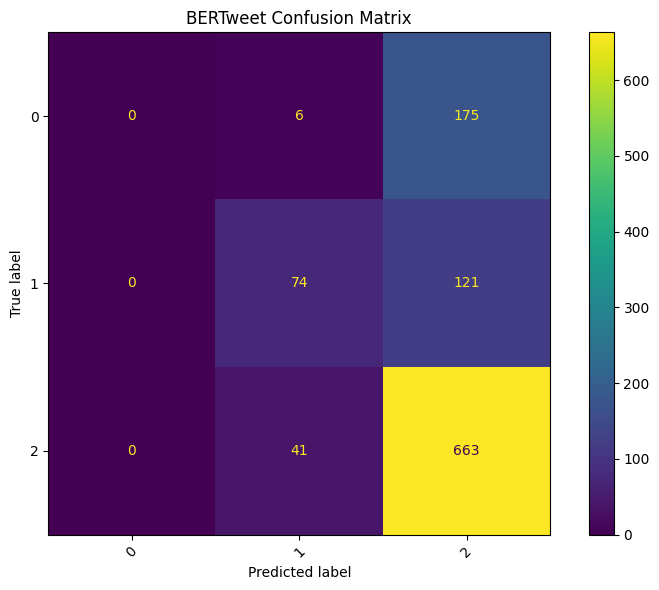

In [14]:
# =========================
# 14. Confusion matrix
# =========================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "BERTweet Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "bertweet_confusion_matrix.png",
    dpi=300
)

plt.show()

In [15]:
# =========================
# 15. Save predictions
# =========================

test_output = test_df.copy()

test_output["predicted_label_id"] = y_pred

test_output["predicted_label"] = [
    id2label[int(i)]
    for i in y_pred
]

test_output["true_label"] = [
    id2label[int(i)]
    for i in y_true
]

test_output.to_csv(
    "bertweet_test_predictions.csv",
    index=False
)

print(
    "Predictions saved successfully"
)

test_output.head()

Predictions saved successfully


,text,label,labels,predicted_label_id,predicted_label,true_label
0,Atheism [SEP] he who exalts himself shall be h...,2,2,2,2,2
1,Atheism [SEP] rt : i remove nehushtan -previou...,2,2,2,2,2
2,Atheism [SEP] i have sought the truth of my so...,2,2,2,2,2
3,Atheism [SEP] #god is utterly powerless withou...,2,2,2,2,2
4,Atheism [SEP] miracles of #multiculturalism mi...,2,2,2,2,2


In [16]:
# =========================
# 16. Save final model
# =========================

trainer.save_model(
    "./final_bertweet_model"
)

tokenizer.save_pretrained(
    "./final_bertweet_model"
)

print(
    "Model and tokenizer saved successfully"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully
